Welcome to your first Jupyter notebook! Please edit this document with your answers, and eventually upload to canvas or however George tells you to.

# Notebook Setup

In [1]:
# load numerical packages
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

**NOTE:** Please run the following cell before skipping to any section. **Do not** change it without knowing what you're doing.

### **Problem 1 & 2**

Suppose that a genie gave you a number equally likely to be anywhere on the $[0,1]$ line. One way to do this in Python (similar to Matlab), is by calling `numpys` `random.rand` function. You can read its documentation [here](http://docs.scipy.org/doc/numpy/reference/generated/numpy.random.rand.html)

In [2]:
u = np.random.rand()
u

0.09084986378968485

Suppose that you wanted to generate a number that is $1$ with probability $0.75$ and $0$ with probability $0.25$. Edit the cell below to correctly generate this number.

In [3]:
# generate random number
u = np.random.rand()

# make comparsion
if u < 0.75:
    coinFlip = 1
else:
    coinFlip = 0

# print result
print(coinFlip)

1


Now, we're going to create a function `generateRandomCoinFlip` that generates a random coin flip that is $1$ with probability $p$. This is a function where $p$ is an input and $outcome$ is the output.

In [4]:
def generateRandomCoinFlip(p):
    u = np.random.rand()
    if u < p:
        outcome = 1
    else:
        outcome = 0
    return outcome

Now run the cell below a bunch of times with different values for $p$ and watch what happebs.

In [5]:
p = 0.75
flipValue = generateRandomCoinFlip(p)
print(flipValue)

1


Now we're going to create a new function called `generateRandomBinaryVector(p,n)`. Here, create a vector of length $n$ where each entry is the outcome of a coinflip where the probability of heads was $p$. Specifically, I want you to call the function `generateRandomCoinFlip` here, otherwise you do not get full credit.

**Note:** The documentation for the `zeros` function can be found [here](http://docs.scipy.org/doc/numpy/reference/generated/numpy.zeros.html)

In [6]:
def generateRandomBinaryVector(p,n):
    outcomes = np.zeros((n,1))

    for index in range(0,n):
        # assign the index entry of outcomes
        outcomes[index,0] = generateRandomCoinFlip(p)

    return outcomes

Now we're going to visualize the outcomes of our functions. Create a `stem` plot of the following:
* coinflips with $n=20$, $p=0.3$
* coinflips with $n=20$, $p=0.8$

Also, make sure you edit the x label, y label, and title to describe that the x axis pertains to which of the $20$ coin flips, the y-axis corresponds to the outcome of the coinflip, and title denotes that there are $20$ coinflips and what $p$ is. **You should have two plots.** You should first call `generateRandomBinaryVector` and then do your plotting.

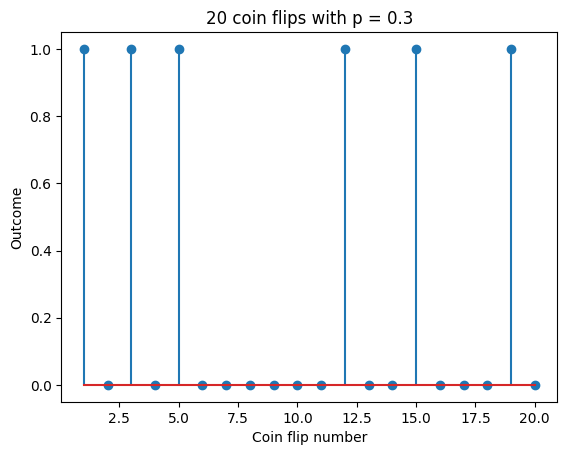

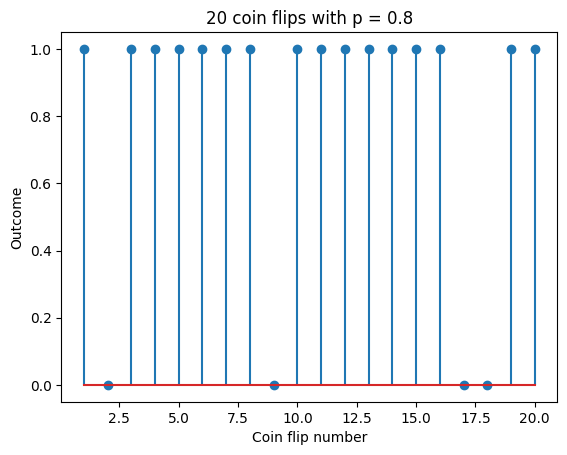

In [7]:
# coin flips with n = 20, p = 0.3
outcomes1 = generateRandomBinaryVector(0.3, 20)
x1 = np.arange(1, 21)

plt.figure()
plt.stem(x1, outcomes1)
plt.xlabel('Coin flip number')
plt.ylabel('Outcome')
plt.title('20 coin flips with p = 0.3')
plt.show()

# coin flips with n = 20, p = 0.8
outcomes2 = generateRandomBinaryVector(0.8, 20)
x2 = np.arange(1, 21)

plt.figure()
plt.stem(x2, outcomes2)
plt.xlabel('Coin flip number')
plt.ylabel('Outcome')
plt.title('20 coin flips with p = 0.8')
plt.show()

### **3. Equivalence of events**


#### (a) Show that A=B

**show that if ω ∈ A, then ω ∈ B.**
  
If $\omega \in A$, then by definition $\omega \geq 2$.

Since log is increasing on $[0,\infty)$, taking log of both sides gives
$\log(\omega) \geq \log(2)$.

Therefore $\omega \in B$, thus $A \subset B$.


**show that if ω ∈ B, then ω ∈ A.**

If $\omega \in B$, then by definition
$\log(\omega) \geq \log(2)$.

Again, because log is increasing, this implies
$\omega \geq 2$.

Therefore $\omega \in A$.

So every element of $B$ is also in $A$, and hence $B \subset A$.


In [8]:
# (a)
import numpy as np

def in_A(omega):
    return omega >= 2

def in_B(omega):
    return np.log(omega) >= np.log(2)

def count_A_not_in_B(num_samples=1000, low=1e-6, high=100):
    omegas = np.random.uniform(low, high, num_samples)
    inconsistencies = 0

    for omega in omegas:
        if in_A(omega) and not in_B(omega):
            inconsistencies += 1

    return inconsistencies

def count_B_not_in_A(num_samples=10000, low=1e-6, high=100):
    omegas = np.random.uniform(low, high, num_samples)
    inconsistencies = 0

    for omega in omegas:
        if in_B(omega) and not in_A(omega):
            inconsistencies += 1

    return inconsistencies

# example usage
print("A not in B inconsistencies:", count_A_not_in_B(1000))
print("B not in A inconsistencies:", count_B_not_in_A(1000))

A not in B inconsistencies: 0
B not in A inconsistencies: 0


#### (b) Show that C = D.



If $\omega \in C$, then by definition $\omega < -5$.

Multiplying both sides by minus reverses the inequality, so
$-\omega > 5$.

Since the exponential function is increasing, this gives
$e^{-\omega} > e^5$, thus $\omega \in D$ and $C \subset D$.

The reverse is the same approach, with multiplcation of -1 and log leading to C.


Therefore,
$$
C = D
$$

In [9]:
import numpy as np

def in_C(omega):
    return omega <= -5

def in_D(omega):
    return np.exp(-omega) >= np.exp(5)

def count_inconsistencies(num_samples=10000, low=-20, high=20):
    omegas = np.random.uniform(low, high, num_samples)
    C_not_D = 0
    D_not_C = 0

    for omega in omegas:
        if in_C(omega) and not in_D(omega):
            C_not_D += 1
        if in_D(omega) and not in_C(omega):
            D_not_C += 1

    return C_not_D, D_not_C

C_not_D, D_not_C = count_inconsistencies(10000)

print("C not in D inconsistencies:", C_not_D)
print("D not in C inconsistencies:", D_not_C)

C not in D inconsistencies: 0
D not in C inconsistencies: 0


#### (c) Show that E = F
When $\Omega = [0,\infty)$,



If $\omega \in E$, then by definition $\omega \leq 9$.

Also, since $\omega \in \Omega = [0,\infty)$, we have $\omega \geq 0$, so $\sqrt{\omega}$ is well-defined.

Because the square-root function is increasing on $[0,\infty)$, from $\omega \leq 9$ we get
$\sqrt{\omega} \leq \sqrt{9} = 3$.

Therefore $\omega \in F$, leading to $E \subset F$.



If $\omega \in F$, then by definition
$\sqrt{\omega} \leq 3$.

Since both sides are nonnegative, squaring preserves the inequality, so
$\omega \leq 9$.

Therefore $\omega \in E$ that leads to $F \subset E$.

Therefore,
$$
E = F
$$

**What happens if the solution space is the total real number?**

When $\Omega = \mathbb{R}$:




$$
E = \{\omega \in \mathbb{R} : \omega \leq 9\}
$$
but
$$
F = \{\omega \in \mathbb{R} : \sqrt{\omega} \leq 3\}.
$$

Since $\sqrt{\omega}$ is only defined for $\omega \geq 0$, the set $F$ contains only real numbers with
$0 \leq \omega \leq 9$.

So in this case,
$$
F = \{\omega \in \mathbb{R} : 0 \leq \omega \leq 9\}.
$$


Thus there is an element of $E$ that is not in $F$, (such as -1) which shows
$$
E \neq F.
$$

In [10]:
import numpy as np

def in_E(omega):
    return omega <= 9

def in_F(omega):
    return np.sqrt(omega) <= 3

def count_inconsistencies(num_samples=1000, low=0, high=20):
    omegas = np.random.uniform(low, high, num_samples)
    E_not_F = 0
    F_not_E = 0

    for omega in omegas:
        if in_E(omega) and not in_F(omega):
            E_not_F += 1
        if in_F(omega) and not in_E(omega):
            F_not_E += 1

    return E_not_F, F_not_E

E_not_F, F_not_E = count_inconsistencies(1000)

print("E not in F inconsistencies:", E_not_F)
print("F not in E inconsistencies:", F_not_E)

E not in F inconsistencies: 0
F not in E inconsistencies: 0


Showing that if Ω=R, then E does not equal to F because E includes all real numbers while in F, square root w is not a real number when w is a negative. 

In [11]:
# For example when w is -1, it will give invalid warning
import numpy as np

omega = -1

E = omega <= 9
F = np.sqrt(omega) <= 3

print("omega in E:", E)
print("omega in F:", F)

omega in E: True
omega in F: False


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_42940\626746931.py:7: RuntimeWarning: invalid value encountered in sqrt
  F = np.sqrt(omega) <= 3


#### (d) Use your reasoning in previous parts of the problem to argue that: 

**(i) if g is monotonically increasingover Ω, then A = B.**




If $\omega \in A$, then by definition
$a \leq \omega \leq b$.

Since $g$ is monotonically increasing, applying $g$ preserves the inequalities, so
$g(a) \leq g(\omega) \leq g(b)$.

Therefore $\omega \in B$ and thus $A \subset B$.

If $\omega \in B$, then by definition
$g(a) \leq g(\omega) \leq g(b)$.

Since $g$ is monotonically increasing and invertible, applying $g^{-1}$ preserves the inequalities, so
$a \leq \omega \leq b$.

Therefore $\omega \in A$ and thus $B \subset A$.

Therefore,
$$
A = B
$$


**(ii) if g is monotonically decreasing \ over Ω, then show A = C**



If $\omega \in A$, then by definition
$a \leq \omega \leq b$.

Since $g$ is monotonically decreasing, applying $g$ reverses the inequalities, so
$g(a) \geq g(\omega) \geq g(b)$.

Therefore $\omega \in C$, leading to  $A \subset C$.

Vice versa,

If $\omega \in C$, then by definition
$g(a) \geq g(\omega) \geq g(b)$.

Since $g$ is monotonically decreasing and invertible, applying $g^{-1}$ reverses the inequalities, so
$a \leq \omega \leq b$.

Therefore $\omega \in A$, leading to $C \subset A$.

Therefore,
$$
A = C
$$

**(iii) What happens of g is not invertible for soulution space?**
If $g$ is not invertible on $\Omega$, then in general we cannot say that $A = B$ or $A = C$, as $g$ is not one-to-one, knowing that
$g(a) \leq g(\omega) \leq g(b)$
or
$g(a) \geq g(\omega) \geq g(b)$
does not necessarily force
$a \leq \omega \leq b$.


For example, let
$$
g(\omega)=\omega^2,\qquad a=1,\qquad b=2.
$$

Then
$$
A=\{\omega\in\mathbb{R}:1\leq \omega \leq 2\}=[1,2].
$$

Also,
$$
g(a)=1,\qquad g(b)=4.
$$

So
$$
B=\{\omega\in\mathbb{R}:1\leq g(\omega)\leq 4\}
=\{\omega\in\mathbb{R}:1\leq \omega^2\leq 4\}.
$$


Therefore, 
$$
A\neq B.
$$


### **4. Taylor series**
#### (a) Show using a first order Taylor series expansion for the function f (x) = log(1 − x), that the following holds for small ∆
* Let f(x) = log(1-x)
* f(0) = log(1) = 0
* f'(0) = -1/1= -1
* first order Taylor expansion at x=0 is f(x) ~= f(0) + f'(0)x = -x
* Now if x=λΔ, for small Δ, x=λΔ is also small, so log(1−λΔ)≈−λΔ.
  

In [12]:
import numpy as np

lam = 2
Delta_values = np.array([0.001, 0.01, 0.05, 0.1])

for Delta in Delta_values:
    exact = np.log(1 - lam * Delta)
    approx = -lam * Delta
    
    print(f"Delta = {Delta}")
    print(f"log(1 - lambda*Delta) = {exact}")
    print(f"-lambda*Delta = {approx}")
    print(f"difference = {abs(exact - approx)}")
    print()

Delta = 0.001
log(1 - lambda*Delta) = -0.0020020026706730793
-lambda*Delta = -0.002
difference = 2.002670673079219e-06

Delta = 0.01
log(1 - lambda*Delta) = -0.020202707317519466
-lambda*Delta = -0.02
difference = 0.00020270731751946547

Delta = 0.05
log(1 - lambda*Delta) = -0.10536051565782628
-lambda*Delta = -0.1
difference = 0.005360515657826276

Delta = 0.1
log(1 - lambda*Delta) = -0.2231435513142097
-lambda*Delta = -0.2
difference = 0.023143551314209698



#### (b) Show that for a fixed t > 0
* let yΔ​=(1−λΔ)t/Δ.
* Then logyΔ​=Δt​log(1−λΔ).
* From part (a), log(1−λΔ)∼−λΔas Δ→0
* so Δt/Δ *​log(1−λΔ)∼Δt​(−λΔ)=−λt.
* Hence lim ​logyΔ​ = −λt.

In [13]:
import numpy as np

lam = 2
t = 3
Delta_values = [0.1, 0.05, 0.01, 0.005, 0.001] # I chose random deltas

for Delta in Delta_values:
    value = (1 - lam * Delta)**(t / Delta)
    target = np.exp(-lam * t)
    diff = abs(value - target)

    print(f"Delta = {Delta}")
    print(f"(1 - lambda*Delta)^(t/Delta) = {value}")
    print(f"exp(-lambda*t) = {target}")
    print(f"difference = {diff}")
    print()

Delta = 0.1
(1 - lambda*Delta)^(t/Delta) = 0.0012379400392853823
exp(-lambda*t) = 0.0024787521766663585
difference = 0.0012408121373809762

Delta = 0.05
(1 - lambda*Delta)^(t/Delta) = 0.001797010299914434
exp(-lambda*t) = 0.0024787521766663585
difference = 0.0006817418767519246

Delta = 0.01
(1 - lambda*Delta)^(t/Delta) = 0.002332505667951413
exp(-lambda*t) = 0.0024787521766663585
difference = 0.00014624650871494565

Delta = 0.005
(1 - lambda*Delta)^(t/Delta) = 0.0024050092913110673
exp(-lambda*t) = 0.0024787521766663585
difference = 7.374288535529116e-05

Delta = 0.001
(1 - lambda*Delta)^(t/Delta) = 0.0024639044511152106
exp(-lambda*t) = 0.0024787521766663585
difference = 1.4847725551147932e-05



### (c)
* Because g is monotonically increasing, it preserves orders. so for any x1, x2, f(x1) <= f(x2) <=> g(f(x1)) <= g(f(x2))
* since h(x) = g(f(x)), this means f(x1) <= f(x2) <=> h(x1) <= h(x2)
* So the point that gives the smallest value of f also gives the smallest value of h
* Now apply this to the given function, and take g(y) = -logy which is monotonically increasing  for y > 0 since g'(y) = -1/y <0

### **5. Prove De Morgan's law**



#### (a) Prove De Mrgan's law 

- First law


$$
(A \cup B)^c = A^c \cap B^c
$$

Show $(A \cup B)^c \subseteq A^c \cap B^c$:

If $x \in (A \cup B)^c$, then $x \notin A \cup B$.

So $x \notin A$ and $x \notin B$.

Therefore $x \in A^c$ and $x \in B^c$, so $x \in A^c \cap B^c$.

Show $A^c \cap B^c \subseteq (A \cup B)^c$:

If $x \in A^c \cap B^c$, then $x \in A^c$ and $x \in B^c$.

So $x \notin A$ and $x \notin B$.

Therefore $x \notin A \cup B$, which means $x \in (A \cup B)^c$.

Thus the amswer is,

$$
(A \cup B)^c = A^c \cap B^c
$$

- The secondd law
$$
(A \cap B)^c = A^c \cup B^c
$$

Show $(A \cap B)^c \subseteq A^c \cup B^c$:

If $x \in (A \cap B)^c$, then $x \notin A \cap B$.

So it is not true that $x \in A$ and $x \in B$.

Therefore $x \notin A$ or $x \notin B$.

So $x \in A^c$ or $x \in B^c$, which means $x \in A^c \cup B^c$.

Show $A^c \cup B^c \subseteq (A \cap B)^c$:

If $x \in A^c \cup B^c$, then $x \in A^c$ or $x \in B^c$.

So $x \notin A$ or $x \notin B$.

Therefore $x \notin A \cap B$, which means $x \in (A \cap B)^c$.

Thus the amswer is,

$$
(A \cap B)^c = A^c \cup B^c
$$


#### (b)  Calculate P (A1 ∪ A2 ∪ A3).


Use De Morgan's law:

$$
(A_1 \cup A_2 \cup A_3)^c = A_1^c \cap A_2^c \cap A_3^c
$$

So,

$$
P(A_1 \cup A_2 \cup A_3) = 1 - P(A_1^c \cap A_2^c \cap A_3^c)
$$

Since $A_1, A_2, A_3$ are statistically independent, their complements are also independent. Therefore,

$$
P(A_1^c \cap A_2^c \cap A_3^c) = P(A_1^c)P(A_2^c)P(A_3^c)
$$

Now compute each complement probbability:

$$
P(A_1^c) = 1 - P(A_1) = 1 - 0.8 = 0.2
$$

$$
P(A_2^c) = 1 - P(A_2) = 1 - 0.35 = 0.65
$$

$$
P(A_3^c) = 1 - P(A_3) = 1 - 0.75 = 0.25
$$

Thus,

$$
P(A_1^c \cap A_2^c \cap A_3^c) = (0.2)(0.65)(0.25) = 0.0325
$$

Therefore,

$$
P(A_1 \cup A_2 \cup A_3) = 1 - 0.0325 = 0.9675
$$

Thererfore, the answer is

$$
P(A_1 \cup A_2 \cup A_3) = 0.9675
$$

In [14]:
P_A1 = 0.8
P_A2 = 0.35
P_A3 = 0.75

P_A1c = 1 - P_A1
P_A2c = 1 - P_A2
P_A3c = 1 - P_A3

P_union = 1 - (P_A1c * P_A2c * P_A3c)

print(P_union)

0.9675


### **6. Prior likelihood**
#### (a) Draw a sequential description of the sample space

A sequential description first chooses whether the drug has a manufacturing defect, and then chooses the FDA risk level conditional on that outcome.

Let

- \(D\) = drug has a defect
- \(D^c\) = drug does not have a defect

Then

$$
P(D) = 0.1, \qquad P(D^c) = 0.9
$$

If there is no defect, the risk levels are:

$$
P(0 \mid D^c) = 0.7, \quad P(1 \mid D^c) = 0.2, \quad P(2 \mid D^c) = 0.1
$$

If there is a defect, the risk levels are:

$$
P(1 \mid D) = 0.3, \quad P(2 \mid D) = 0.5, \quad P(3 \mid D) = 0.2
$$

So the sequential sample-space tree is:

- \(D^c\) with probability \(0.9\)
  - risk \(0\) with probability \(0.7\)
  - risk \(1\) with probability \(0.2\)
  - risk \(2\) with probability \(0.1\)

- \(D\) with probability \(0.1\)
  - risk \(1\) with probability \(0.3\)
  - risk \(2\) with probability \(0.5\)
  - risk \(3\) with probability \(0.2\)


#### (b) Calculate the probability that there is a drug defect and the risk level equals 2.

In [15]:
P_defect = 0.1
P_risk2_given_defect = 0.5

P_defect_and_risk2 = P_defect * P_risk2_given_defect

print(P_defect_and_risk2)

0.05


#### (c) Calculate the probability the risk level equals 2.

In [16]:
P_defect = 0.1
P_no_defect = 0.9

P_risk2_given_defect = 0.5
P_risk2_given_no_defect = 0.1

P_risk2 = P_defect * P_risk2_given_defect + P_no_defect * P_risk2_given_no_defect

print(P_risk2)

0.14


#### (d) Calculate the probability there is a defect given the risk level equals 1.

In [17]:
P_defect = 0.1
P_no_defect = 0.9

P_risk1_given_defect = 0.3
P_risk1_given_no_defect = 0.2

P_risk1 = P_risk1_given_defect * P_defect + P_risk1_given_no_defect * P_no_defect
P_defect_given_risk1 = (P_risk1_given_defect * P_defect) / P_risk1

print(P_defect_given_risk1)

0.14285714285714285


#### (e) Calculate the probability that the risk level is 1 or 2.

In [18]:
P_defect = 0.1
P_no_defect = 0.9

P_risk1_given_defect = 0.3
P_risk2_given_defect = 0.5

P_risk1_given_no_defect = 0.2
P_risk2_given_no_defect = 0.1

P_risk1_or_2 = (
    P_defect * (P_risk1_given_defect + P_risk2_given_defect)
    + P_no_defect * (P_risk1_given_no_defect + P_risk2_given_no_defect)
)

print(P_risk1_or_2)

0.3500000000000001


#### (f) Calculate the probability that there is a drug defect given the readout equals 1 or 2.

In [19]:
# requires Bayes' rule of readout being either 1 or 2
P_defect = 0.1
P_no_defect = 0.9

P_1_or_2_given_defect = 0.3 + 0.5
P_1_or_2_given_no_defect = 0.2 + 0.1

P_1_or_2 = (
    P_1_or_2_given_defect * P_defect
    + P_1_or_2_given_no_defect * P_no_defect
)

P_defect_given_1_or_2 = (P_1_or_2_given_defect * P_defect) / P_1_or_2

print(P_defect_given_1_or_2)

0.22857142857142856


### **7. Fraction of people in the US**
#### (a) develop a sequential description of Ω for this problem



Use a three-stage tree:

1. First choose ethnicity.
2. Then choose whether the person has glaucoma, conditional on ethnicity.
3. Then choose whether the IOP reading is abnormal, conditional on whether the person has glaucoma.

Let

- \(W\) = white
- \(B\) = black
- \(O\) = other
- \(G\) = has glaucoma
- \(G^c\) = does not have glaucoma
- \(A\) = abnormal IOP
- \(A^c\) = normal IOP

Root probabilities:

$$
P(W)=0.40,\qquad P(B)=0.15,\qquad P(O)=0.45
$$

Glaucoma probabilities:

$$
P(G\mid W)=0.30,\qquad P(G^c\mid W)=0.70
$$

$$
P(G\mid B)=0.45,\qquad P(G^c\mid B)=0.55
$$

$$
P(G\mid O)=0.25,\qquad P(G^c\mid O)=0.75
$$

IOP probabilities:

$$
P(A\mid G)=0.65,\qquad P(A^c\mid G)=0.35
$$

$$
P(A\mid G^c)=0.15,\qquad P(A^c\mid G^c)=0.85
$$

So the leaves of the tree are:

- \((W,G,A)\)
- \((W,G,A^c)\)
- \((W,G^c,A)\)
- \((W,G^c,A^c)\)
- \((B,G,A)\)
- \((B,G,A^c)\)
- \((B,G^c,A)\)
- \((B,G^c,A^c)\)
- \((O,G,A)\)
- \((O,G,A^c)\)
- \((O,G^c,A)\)
- \((O,G^c,A^c)\)


#### (b) Are the events A = {person is black} and B = {IOP is normal} statistically independent? Justify your answer.


Let

$$
A=\{\text{person is black}\}
$$

and

$$
B=\{\text{IOP is normal}\}.
$$

To be statistically independent, we would need

$$
P(A \cap B)=P(A)P(B).
$$

First,

$$
P(A)=P(\text{black})=0.15.
$$

Now compute \(P(B)\).

For whites,

$$
P(B \mid W)=P(B \mid G)P(G \mid W)+P(B \mid G^c)P(G^c \mid W)
$$

$$
=(0.35)(0.30)+(0.85)(0.70)=0.105+0.595=0.70.
$$

For blacks,

$$
P(B \mid A)=P(B \mid G)P(G \mid A)+P(B \mid G^c)P(G^c \mid A)
$$

$$
=(0.35)(0.45)+(0.85)(0.55)=0.1575+0.4675=0.625.
$$

For others,

$$
P(B \mid O)=P(B \mid G)P(G \mid O)+P(B \mid G^c)P(G^c \mid O)
$$

$$
=(0.35)(0.25)+(0.85)(0.75)=0.0875+0.6375=0.725.
$$

So,

$$
P(B)=0.40(0.70)+0.15(0.625)+0.45(0.725)
$$

$$
=0.28+0.09375+0.32625=0.70.
$$

Now compute \(P(A \cap B)\):

$$
P(A \cap B)=P(\text{black and normal})=P(\text{black})P(\text{normal} \mid \text{black})
$$

$$
=0.15(0.625)=0.09375.
$$

But

$$
P(A)P(B)=0.15(0.70)=0.105.
$$

Since

$$
P(A \cap B)=0.09375 \ne 0.105=P(A)P(B),
$$

the events are not statistically independent.

Hence,

$$
A \text{ and } B \text{ are not statistically independent.}
$$

In [20]:
P_black = 0.15

P_normal_given_G = 0.35
P_normal_given_notG = 0.85

P_G_given_white = 0.30
P_G_given_black = 0.45
P_G_given_other = 0.25

P_notG_given_white = 0.70
P_notG_given_black = 0.55
P_notG_given_other = 0.75

P_white = 0.40
P_other = 0.45

P_normal_given_white = P_normal_given_G * P_G_given_white + P_normal_given_notG * P_notG_given_white
P_normal_given_black = P_normal_given_G * P_G_given_black + P_normal_given_notG * P_notG_given_black
P_normal_given_other = P_normal_given_G * P_G_given_other + P_normal_given_notG * P_notG_given_other

P_normal = (
    P_white * P_normal_given_white
    + P_black * P_normal_given_black
    + P_other * P_normal_given_other
)

P_A_and_B = P_black * P_normal_given_black
P_A_times_P_B = P_black * P_normal

print(P_A_and_B)
print(P_A_times_P_B)

0.09375
0.105


#### (c) given that an individual is black and their IOP is normal, what is the likelihood they have glaucoma?


In [21]:
P_black = 0.15
P_G_given_black = 0.45
P_normal_given_G = 0.35
P_normal_given_black = 0.625

P_G_and_black_and_normal = P_black * P_G_given_black * P_normal_given_G
P_black_and_normal = P_black * P_normal_given_black

P_G_given_black_and_normal = P_G_and_black_and_normal / P_black_and_normal

print(P_G_given_black_and_normal)

0.252
